In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir(r"C:\Users\echev\OneDrive\Desktop\garalen_variance")
print(os.getcwd())
df = pd.read_csv("data/simulation.csv")
print(df.shape)
print(df.mission_id.unique())

C:\Users\echev\OneDrive\Desktop\garalen_variance
(26040, 5)
<StringArray>
[     'crisa', 'mission_01', 'mission_02', 'mission_03', 'mission_04',
 'mission_05', 'mission_06', 'mission_07', 'mission_08', 'mission_09',
 'mission_10', 'mission_11', 'mission_12', 'mission_13', 'mission_14',
 'mission_15', 'mission_16', 'mission_17', 'mission_18', 'mission_19',
 'mission_20', 'mission_21', 'mission_22', 'mission_23', 'mission_24',
 'mission_25', 'mission_26', 'mission_27', 'mission_28', 'mission_29',
 'mission_30']
Length: 31, dtype: str


In [3]:
from garalen.config import ModelConfig
from garalen.simulation import run_simulation

config_test = ModelConfig(sigma_obs=0.0)
result_test = run_simulation(config_test)

In [4]:
from generate_data import to_dataframe

df_test = to_dataframe(result_test, config_test)

In [5]:
df = df_test

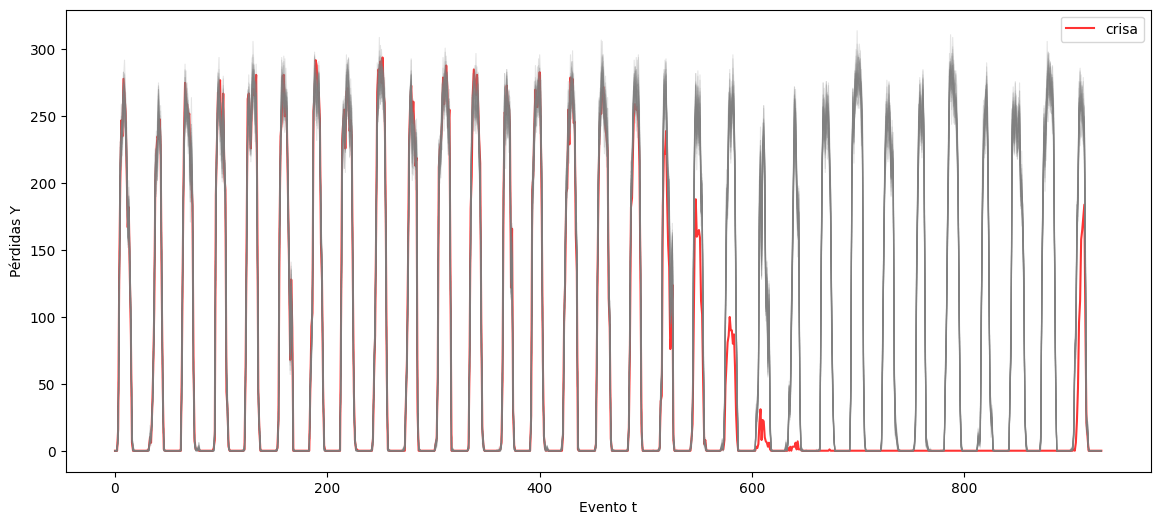

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

for mission in df.mission_id.unique():
    datos = df[df.mission_id == mission]
    if mission == "crisa":
        ax.plot(datos.t, datos.Y, color="red", alpha=0.8, linewidth=1.5, label="crisa")
    else:
        ax.plot(datos.t, datos.Y, color="gray", alpha=0.2, linewidth=0.8)

ax.set_xlabel("Evento t")
ax.set_ylabel("Pérdidas Y")
ax.legend()
plt.show()

In [7]:
Y_ref = df.groupby("t")["Y"].mean().values

umbral = 2
es_cero = Y_ref <= umbral

cruces = np.diff(es_cero.astype(int))
inicios = np.where(cruces == -1)[0] + 1
fines = np.where(cruces == 1)[0]

pares = [(ini, fin) for ini, fin in zip(inicios, fines) if fin > ini + 2]
print(f"Ventanas detectadas: {len(pares)}")

Ventanas detectadas: 31


In [8]:
misiones = df.mission_id.unique()
resultados = []

for mission in misiones:
    Y = df[df.mission_id == mission]["Y"].values
    for ini, fin in pares:
        segmento = Y[ini:fin]
        if len(segmento) > 2:
            resultados.append({
                "mission_id": mission,
                "centro": (ini + fin) / 2,
                "varianza": segmento.var(),
                "maximo": segmento.max()
            })

res = pd.DataFrame(resultados)
ventanas = res.centro.unique()
print(res.head())

print(len(pares))
print(df_test.mission_id.unique())
print(res.mission_id.unique())

  mission_id  centro     varianza  maximo
0      crisa     9.5  5510.591716   278.0
1      crisa    39.0  8578.138889   248.0
2      crisa    69.0  4916.638889   275.0
3      crisa   100.5  8544.284024   277.0
4      crisa   129.5  6036.213018   281.0
31
<StringArray>
[     'crisa', 'mission_01', 'mission_02', 'mission_03', 'mission_04',
 'mission_05', 'mission_06', 'mission_07', 'mission_08', 'mission_09',
 'mission_10', 'mission_11', 'mission_12', 'mission_13', 'mission_14',
 'mission_15', 'mission_16', 'mission_17', 'mission_18', 'mission_19',
 'mission_20', 'mission_21', 'mission_22', 'mission_23', 'mission_24',
 'mission_25', 'mission_26', 'mission_27', 'mission_28', 'mission_29',
 'mission_30']
Length: 31, dtype: str
<StringArray>
[     'crisa', 'mission_01', 'mission_02', 'mission_03', 'mission_04',
 'mission_05', 'mission_06', 'mission_07', 'mission_08', 'mission_09',
 'mission_10', 'mission_11', 'mission_12', 'mission_13', 'mission_14',
 'mission_15', 'mission_16', 'mission_17

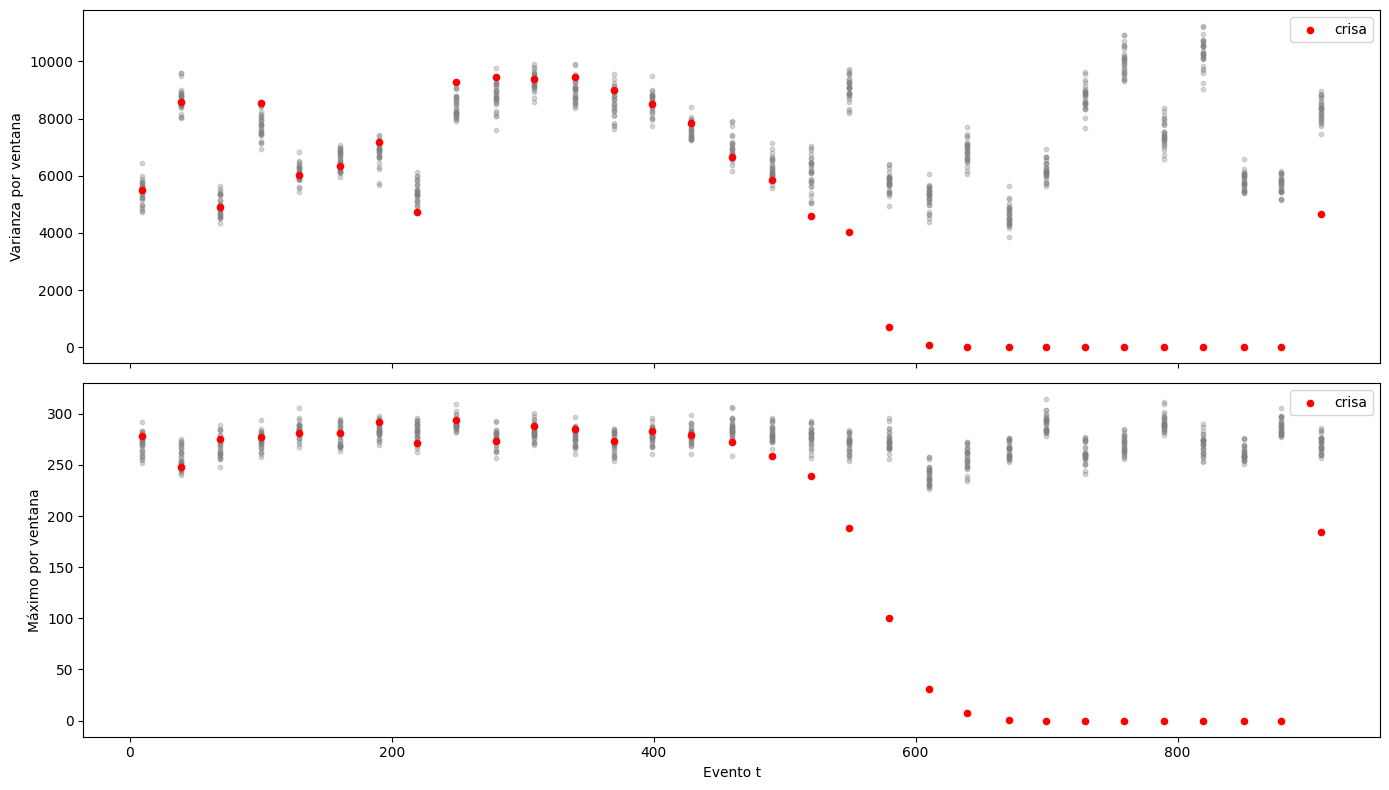

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for mission in misiones:
    datos = res[res.mission_id == mission]
    if mission == "crisa":
        axes[0].scatter(datos.centro, datos.varianza, color="red", s=20, zorder=5, label="crisa")
        axes[1].scatter(datos.centro, datos.maximo, color="red", s=20, zorder=5, label="crisa")
    else:
        axes[0].scatter(datos.centro, datos.varianza, color="gray", alpha=0.3, s=10)
        axes[1].scatter(datos.centro, datos.maximo, color="gray", alpha=0.3, s=10)

axes[0].set_ylabel("Varianza por ventana")
axes[1].set_ylabel("Máximo por ventana")
axes[1].set_xlabel("Evento t")
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
for v in ventanas:
    datos_v = res[res.centro == v]
    for mission in misiones:
        filas = datos_v[datos_v.mission_id == mission]
        if len(filas) == 0:
            print(f"Falta: mission={mission}, ventana={v}")

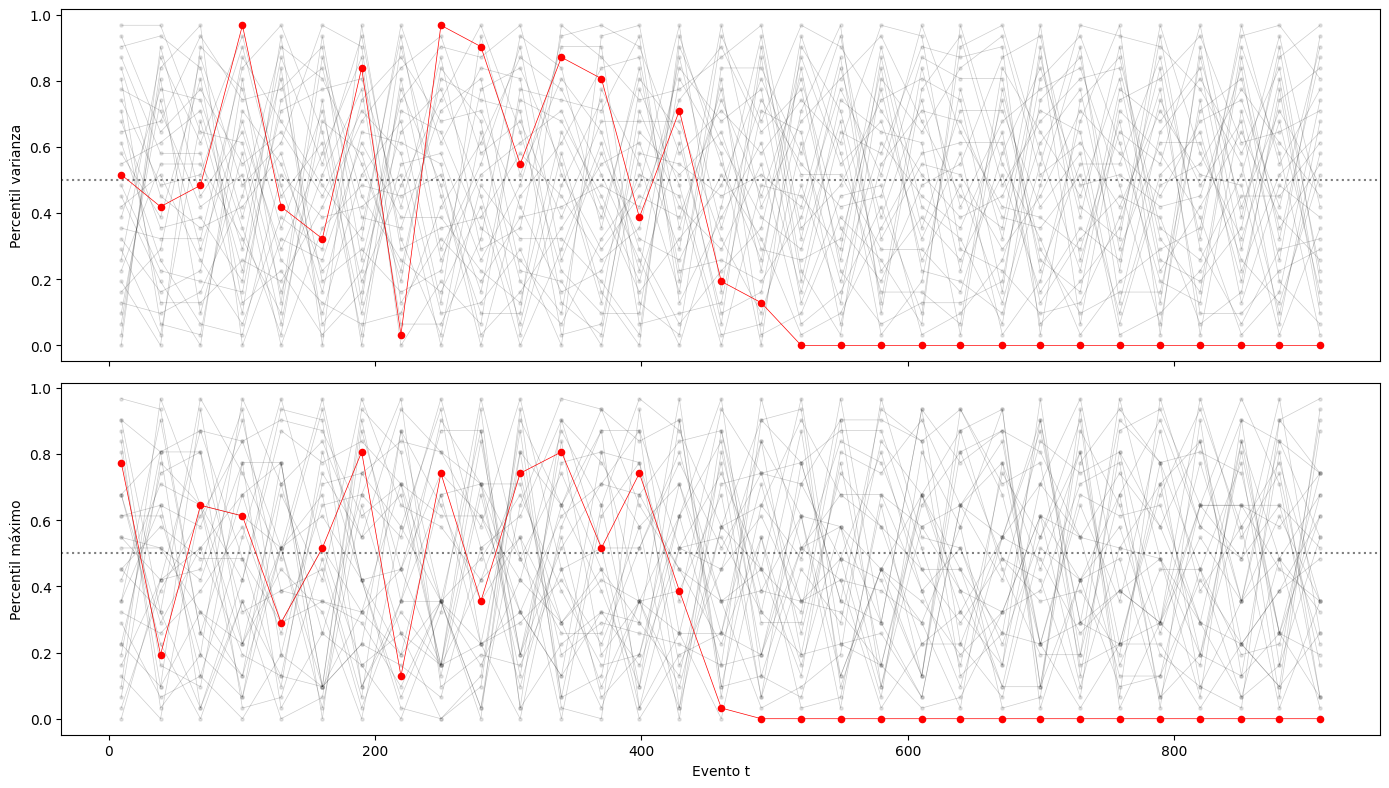

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for mission in misiones:
    perc_var = []
    perc_max = []
    for v in ventanas:
        datos_v = res[res.centro == v]
        val_var = datos_v[datos_v.mission_id == mission]["varianza"].values[0]
        val_max = datos_v[datos_v.mission_id == mission]["maximo"].values[0]
        perc_var.append((val_var > datos_v["varianza"]).mean())
        perc_max.append((val_max > datos_v["maximo"]).mean())
    
    if mission == "crisa":
        axes[0].plot(ventanas, perc_var, color="red", linewidth=0.5, zorder=5)
        axes[0].scatter(ventanas, perc_var, color="red", s=20, zorder=6)
        axes[1].plot(ventanas, perc_max, color="red", linewidth=0.5, zorder=5)
        axes[1].scatter(ventanas, perc_max, color="red", s=20, zorder=6)
    else:
        axes[0].plot(ventanas, perc_var, color="black", alpha=0.2, linewidth=0.5)
        axes[0].scatter(ventanas, perc_var, color="gray", alpha=0.2, s=5)
        axes[1].plot(ventanas, perc_max, color="black", alpha=0.2, linewidth=0.5)
        axes[1].scatter(ventanas, perc_max, color="gray", alpha=0.2, s=5)

axes[0].axhline(0.5, color="black", linestyle=":", alpha=0.5)
axes[1].axhline(0.5, color="black", linestyle=":", alpha=0.5)
axes[0].set_ylabel("Percentil varianza")
axes[1].set_ylabel("Percentil máximo")
axes[1].set_xlabel("Evento t")
plt.tight_layout()
plt.show()

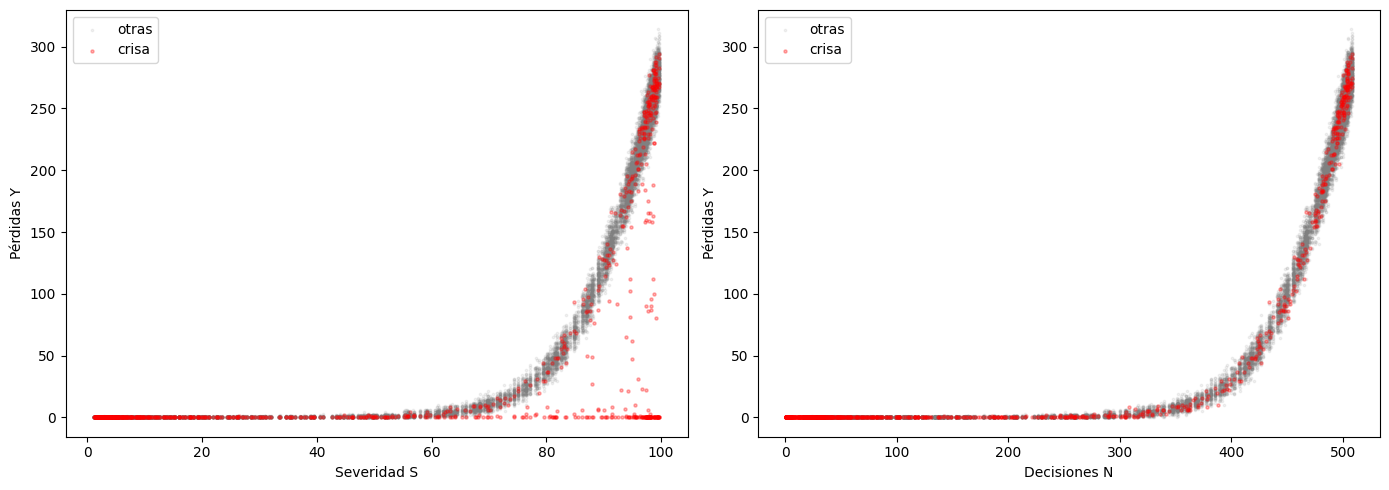

In [12]:
crisa = df[df.mission_id == "crisa"]
otras = df[df.mission_id != "crisa"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(otras.S, otras.Y, alpha=0.1, s=3, color="gray", label="otras")
axes[0].scatter(crisa.S, crisa.Y, alpha=0.3, s=5, color="red", label="crisa")
axes[0].set_xlabel("Severidad S")
axes[0].set_ylabel("Pérdidas Y")
axes[0].legend()

axes[1].scatter(otras.N, otras.Y, alpha=0.1, s=3, color="gray", label="otras")
axes[1].scatter(crisa.N, crisa.Y, alpha=0.3, s=5, color="red", label="crisa")
axes[1].set_xlabel("Decisiones N")
axes[1].set_ylabel("Pérdidas Y")
axes[1].legend()

plt.tight_layout()
plt.show()

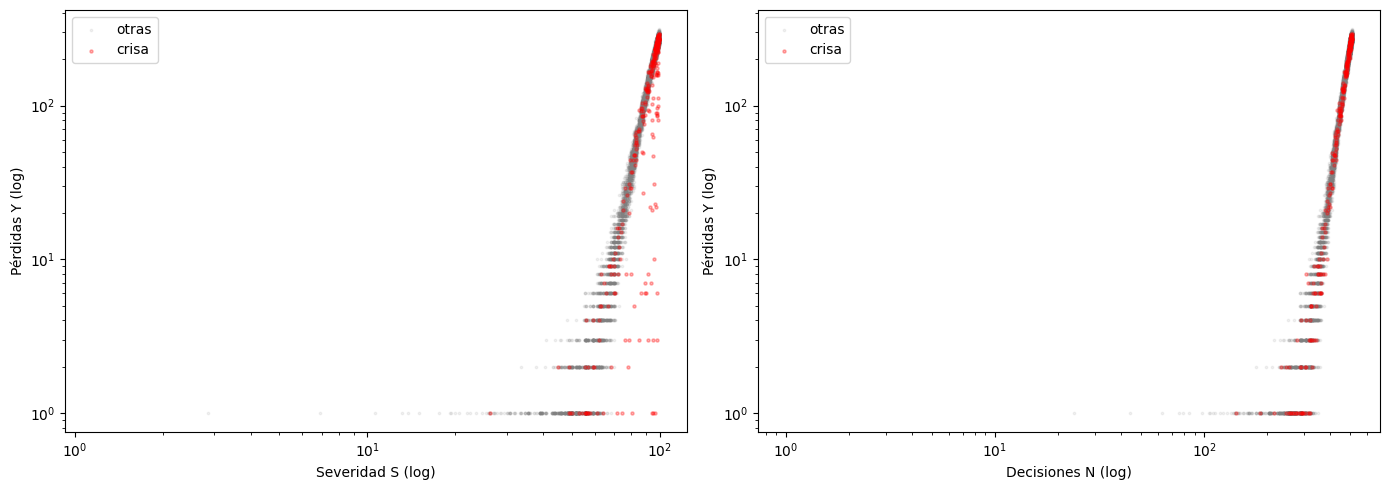

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(otras.S, otras.Y, alpha=0.1, s=3, color="gray", label="otras")
axes[0].scatter(crisa.S, crisa.Y, alpha=0.3, s=5, color="red", label="crisa")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Severidad S (log)")
axes[0].set_ylabel("Pérdidas Y (log)")
axes[0].legend()

axes[1].scatter(otras.N, otras.Y, alpha=0.1, s=3, color="gray", label="otras")
axes[1].scatter(crisa.N, crisa.Y, alpha=0.3, s=5, color="red", label="crisa")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Decisiones N (log)")
axes[1].set_ylabel("Pérdidas Y (log)")
axes[1].legend()

plt.tight_layout()
plt.show()